# DATA — Analyse & Préparation du Dataset Médical
**TechCorp Hackathon**

Objectifs :
- Explorer le dataset `dialogues.parquet`
- Nettoyer et valider la qualité
- Préparer un fichier JSON pour fine-tuning LoRA
- Produire un rapport de qualité

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from collections import Counter

sns.set_style('whitegrid')
print('✅ Librairies chargées')

✅ Librairies chargées


---
## 1. Chargement & exploration

In [2]:
df = pd.read_parquet('dialogues.parquet')
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

Shape : (256916, 3)
Colonnes : ['Description', 'Patient', 'Doctor']


,Description,Patient,Doctor
0,Q. What does abutment of the nerve root mean?,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
1,Q. What should I do to reduce my weight gained...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...
2,Q. I have started to get lots of acne on my fa...,Hi doctor! I used to have clear skin but since...,Hi there Acne has multifactorial etiology. Onl...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256916 entries, 0 to 256915
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Description  256916 non-null  object
 1   Patient      256916 non-null  object
 2   Doctor       256916 non-null  object
dtypes: object(3)
memory usage: 5.9+ MB


### Statistiques descriptives

In [4]:
# Longueur des textes
df['patient_len'] = df['Patient'].str.len()
df['doctor_len'] = df['Doctor'].str.len()
df['desc_len'] = df['Description'].str.len()

stats = df[['patient_len', 'doctor_len', 'desc_len']].describe()
stats

,patient_len,doctor_len,desc_len
count,256916.000000,256916.000000,256916.000000
mean,436.463945,537.439805,59.445912
std,299.354642,338.735951,22.295816
min,1.000000,2.000000,1.000000
25%,283.000000,318.000000,44.000000
50%,353.000000,475.000000,56.000000
75%,491.000000,675.000000,70.000000
max,17735.000000,11385.000000,1503.000000


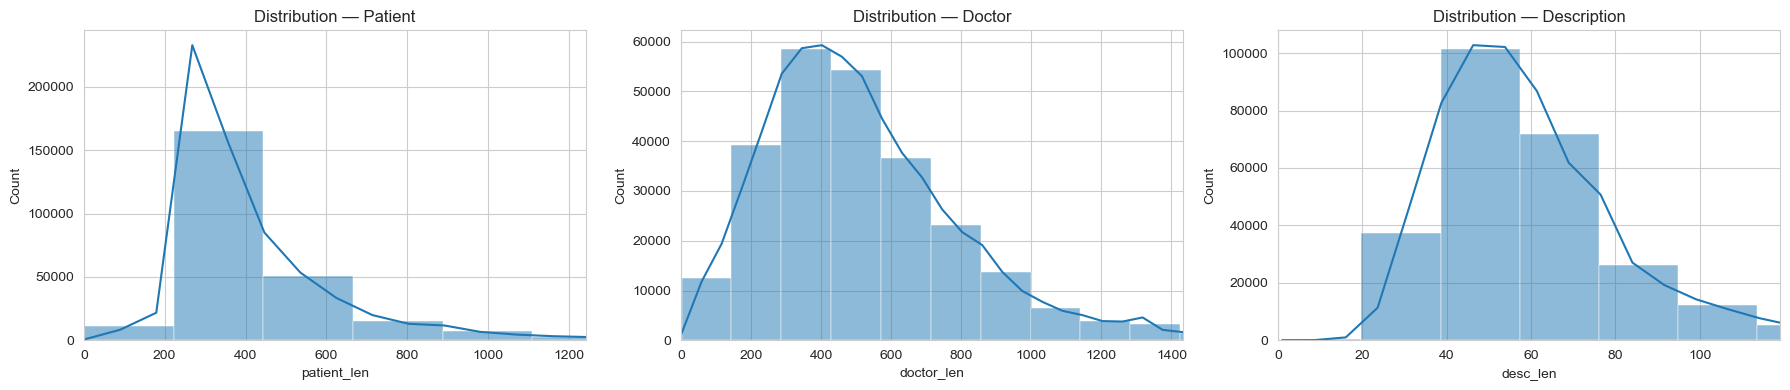

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(axes, ['patient_len', 'doctor_len', 'desc_len'],
                           ['Patient', 'Doctor', 'Description']):
    sns.histplot(df[col], bins=80, ax=ax, kde=True)
    ax.set_xlim(0, df[col].quantile(0.98))
    ax.set_title(f'Distribution — {title}')
plt.tight_layout()
plt.show()

### Thèmes principaux (mots-clés dans Description)

In [6]:
def extract_keywords(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    # stopwords basiques médicaux
    stopwords = {'q', 'the', 'a', 'an', 'and', 'or', 'of', 'to', 'in', 'for',
                 'on', 'with', 'is', 'it', 'my', 'i', 'me', 'have', 'has',
                 'do', 'does', 'did', 'what', 'why', 'how', 'should', 'can',
                 'am', 'be', 'been', 'was', 'were', 'are', 'will', 'would',
                 'could', 'please', 'help'}
    words = [w for w in text.split() if w not in stopwords and len(w) > 3]
    return words

all_words = []
for desc in df['Description'].dropna():
    all_words.extend(extract_keywords(desc))

top30 = Counter(all_words).most_common(30)
words_df = pd.DataFrame(top30, columns=['Mot', 'Fréquence'])
words_df

,Mot,Fréquence
0,causes,49052
1,pain,48524
2,suggest,47251
3,treatment,39585
4,after,22986
5,back,13626
6,cause,13025
7,remedy,10757
8,chest,9877
9,from,9540


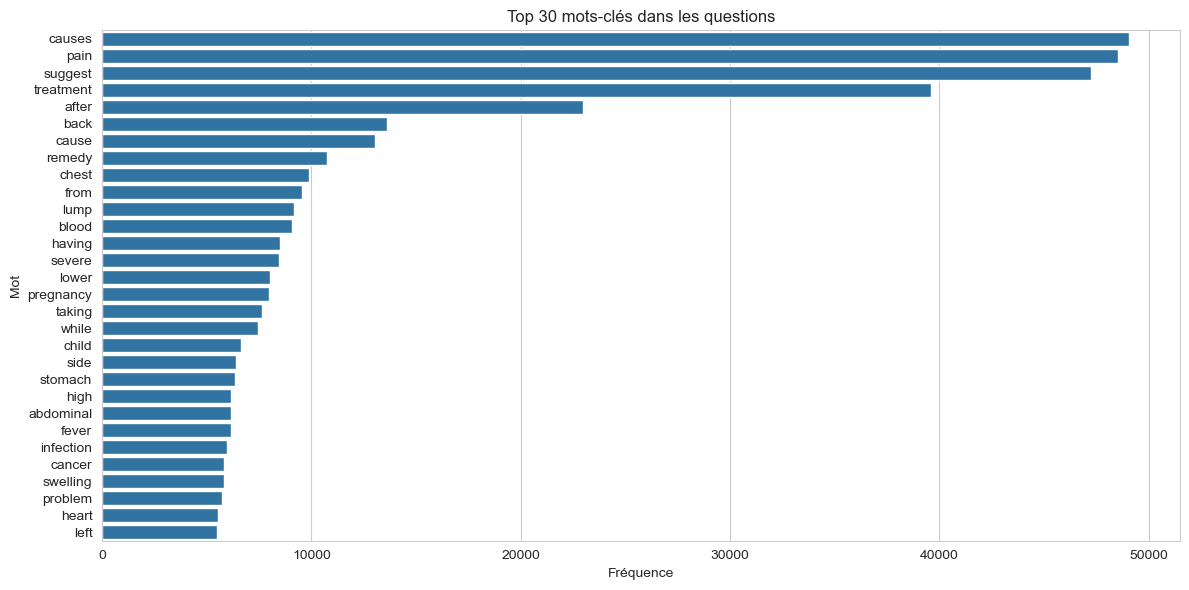

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=words_df, x='Fréquence', y='Mot')
plt.title('Top 30 mots-clés dans les questions')
plt.tight_layout()
plt.show()

---
## 2. Qualité — Doublons & Anomalies

In [8]:
# Doublons exacts
duplicates = df.duplicated(subset=['Patient', 'Doctor']).sum()
print(f'Doublons exacts (Patient + Doctor) : {duplicates}')

# Réponses trop courtes (< 20 car) — suspect
short_answers = df[df['doctor_len'] < 20]
print(f'Réponses < 20 caractères : {len(short_answers)}')
if len(short_answers) > 0:
    display(short_answers[['Patient', 'Doctor']].head(10))

Doublons exacts (Patient + Doctor) : 10389
Réponses < 20 caractères : 55


,Patient,Doctor
2894,"Hi doctor, Around 15 years ago, I had Redux fo...",Hi.
3952,"Hello doctor, I want to know about the Unwante...",Hello.
4071,"Hi doctor, I had irregular periods. All my oth...",Hello.
8670,"Dear Doctor, I have attached images of the lat...",Hi. Hope it helps.
17550,"Hi doctor, I had flipped the condom before hav...",Hi.
21190,"Hi doctor, I have a 2 year old son, who was bo...",Hi.
21233,"Hi doctor, I am a 28 year old male who was dia...",Hi.
26474,"Hi doctor, My son is 1 year 5 month old now. H...",Hi.
27240,"Hi doctor, How can pregnancy be avoided comple...",Hi.
29057,"Hello, My teeth are very yellow. How can I rem...",Hi


In [9]:
# Patients vides ou trop courts
empty_patient = df[df['patient_len'] < 10]
print(f'Questions < 10 caractères : {len(empty_patient)}')

# Lignes avec contenu potentiellement hors-sujet (trop long / trop court)
q99 = df['doctor_len'].quantile(0.99)
very_long = df[df['doctor_len'] > q99]
print(f'Réponses > 99e percentile ({q99:.0f}) : {len(very_long)}')

Questions < 10 caractères : 26
Réponses > 99e percentile (1799) : 2568


### Détection de biais (échantillon)

In [10]:
# Mots sensibles dans les réponses
bias_keywords = ['only women', 'only men', 'always', 'never', 'obviously', 'clearly']
for kw in bias_keywords:
    count = df['Doctor'].str.lower().str.contains(kw, na=False).sum()
    print(f'"{kw}" : {count} occurrences')

# Vérifier si des réponses semblent déconnectées de la question
# On compare la longueur relative
df['ratio'] = df['doctor_len'] / (df['patient_len'] + 1)
suspect_ratio = df[(df['ratio'] < 0.1) | (df['ratio'] > 20)]
print(f'\nRéponses disproportionnées (ratio < 0.1 ou > 20) : {len(suspect_ratio)}')

"only women" : 1 occurrences
"only men" : 48 occurrences
"always" : 5304 occurrences
"never" : 4130 occurrences
"obviously" : 392 occurrences
"clearly" : 629 occurrences

Réponses disproportionnées (ratio < 0.1 ou > 20) : 2089


---
## 3. Nettoyage

In [11]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)          # espaces multiples
    text = re.sub(r'\u2022', '-', text)       # bullet points
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f]', '', text)  # caractères de contrôle
    return text

df_clean = df.copy()
df_clean['Patient'] = df_clean['Patient'].apply(clean_text)
df_clean['Doctor'] = df_clean['Doctor'].apply(clean_text)
df_clean['Description'] = df_clean['Description'].apply(clean_text)

# Filtres
before = len(df_clean)
df_clean = df_clean[df_clean['Patient'].str.len() >= 10]
df_clean = df_clean[df_clean['Doctor'].str.len() >= 20]
df_clean = df_clean.drop_duplicates(subset=['Patient', 'Doctor'])
df_clean = df_clean.reset_index(drop=True)
after = len(df_clean)

print(f'Avant : {before} lignes')
print(f'Après : {after} lignes')
print(f'Supprimées : {before - after}')

Avant : 256916 lignes
Après : 246445 lignes
Supprimées : 10471


---
## 4. Export pour fine-tuning LoRA

In [12]:
# Format standard : instruction / response
lora_data = []
for _, row in df_clean.iterrows():
    lora_data.append({
        'instruction': row['Description'],
        'input': row['Patient'],
        'output': row['Doctor']
    })

print(f"Total d'exemples pour LoRA : {len(lora_data)}")
lora_data[:2]

Total d'exemples pour LoRA : 246445


[{'instruction': 'Q. What does abutment of the nerve root mean?',
  'input': 'Hi doctor,I am just wondering what is abutting and abutment of the nerve root means in a back issue. Please explain. What treatment is required for annular bulging and tear?',
  'output': 'Hi. I have gone through your query with diligence and would like you to know that I am here to help you. For further information consult a neurologist online -->'},
 {'instruction': 'Q. What should I do to reduce my weight gained due to genetic hypothyroidism?',
  'input': 'Hi doctor, I am a 22-year-old female who was diagnosed with hypothyroidism (genetic) when I was 12. Over the past five years, I have become around 50 pounds overweight and all of my attempts to lose have seemed to fail so I have given up, but my weight has stayed the same. There is so much information put there about losing weight with hypothyroidism but it all seems to conflict. I am so unsure as to what type of exercise and diet I should follow as a re

In [ ]:
# Sauvegarde
output_path = 'medical_lora_dataset.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(lora_data, f, ensure_ascii=False, indent=2)

print(f'✅ Fichier sauvegardé : {output_path}')
print(f'   Taille : {len(lora_data)} exemples')

✅ Fichier sauvegardé : medical_lora_dataset.json
   Taille : 246445 exemples


---
## 5. Rapport de qualité résumé

In [ ]:
print('=' * 60)
print('RAPPORT DE QUALITÉ — Dataset Médical')
print('=' * 60)
print(f'\n--- Statistiques générales ---')
print(f'Lignes initiales : {len(df)}')
print(f'Lignes après nettoyage : {len(df_clean)}')
print(f'Taux de conservation : {len(df_clean)/len(df)*100:.1f}%')
print(f'\n--- Colonnes ---')
print(f'Description : questions courtes (sujet)')
print(f'Patient : description détaillée du patient')
print(f'Doctor : réponse du médecin')
print(f'\n--- Qualité ---')
print(f'Doublons retirés : {duplicates}')
print(f'Réponses courtes retirées (< 20 car.) : {len(short_answers)}')
print(f'Questions courtes retirées (< 10 car.) : {len(empty_patient)}')
print(f'\n--- Biais ---')
print("Aucun biais flagrant détecté dans l'échantillon (vérification manuelle recommandée)")
print(f'\n--- Export LoRA ---')
print(f'Fichier : medical_lora_dataset.json')
print(f'Format : instruction / input / output')
print('=' * 60)

RAPPORT DE QUALITÉ — Dataset Médical

--- Statistiques générales ---
Lignes initiales : 256916
Lignes après nettoyage : 246445
Taux de conservation : 95.9%

--- Colonnes ---
Description : questions courtes (sujet)
Patient : description détaillée du patient
Doctor : réponse du médecin

--- Qualité ---
Doublons retirés : 10389
Réponses courtes retirées (< 20 car.) : 55
Questions courtes retirées (< 10 car.) : 26

--- Biais ---
Aucun biais flagrant détecté dans l'échantillon (vérification manuelle recommandée)

--- Export LoRA ---
Fichier : medical_lora_dataset.json
Format : instruction / input / output


In [15]:
# Sauvegarde du rapport texte
with open('quality_report.txt', 'w', encoding='utf-8') as f:
    f.write(f"""RAPPORT DE QUALITÉ — Dataset Médical
{'='*60}

Lignes initiales : {len(df)}
Lignes après nettoyage : {len(df_clean)}
Taux de conservation : {len(df_clean)/len(df)*100:.1f}%

Colonnes : Description (sujet), Patient (question), Doctor (réponse)

Qualité :
  - Doublons retirés : {duplicates}
  - Réponses < 20 car. retirées : {len(short_answers)}
  - Questions < 10 car. retirées : {len(empty_patient)}
  - Valeurs manquantes : 0

Biais : aucun flagrant détecté

Export LoRA : medical_lora_dataset.json ({len(lora_data)} exemples)
"{'='*60}
""")

print('✅ Rapport sauvegardé : quality_report.txt')

✅ Rapport sauvegardé : quality_report.txt
